In [1]:
import numpy as np

# ---------------------------------------------------------
# Two hyperplanes (classifiers) in the form:
#   h(x) = b + w1*x1 + w2*x2
# ---------------------------------------------------------

# Classifier 1: 1 + 5*x1 + 2*x2
b1 = 1
w1 = np.array([5, 2])

# Classifier 2: 3 + 20*x1 + 20*x2
b2 = 3
w2 = np.array([20, 20])


def functional_score(x, w, b):
    """Raw (functional) value of the hyperplane at point x."""
    return np.dot(w, x) + b


def geometric_distance(x, w, b):
    """
    Distance of point x from the hyperplane defined by w, b.
    This is the 'distance error function' -- it normalizes the
    functional score by the norm of w, giving the true
    perpendicular (geometric) distance.
    """
    return functional_score(x, w, b) / np.linalg.norm(w)


def classify(x, w, b):
    """Predicted label based on sign of the hyperplane function."""
    return 1 if functional_score(x, w, b) >= 0 else -1


def evaluate_classifier(name, w, b, points, labels):
    print(f"\n--- {name}: h(x) = {b} + {w[0]}*x1 + {w[1]}*x2 ---")
    total_margin = 0
    correct = 0

    for x, y in zip(points, labels):
        f_score = functional_score(x, w, b)
        g_dist = geometric_distance(x, w, b)
        pred = classify(x, w, b)
        is_correct = (pred == y)
        correct += is_correct

        # signed margin: positive if classified on the correct side
        signed_margin = y * g_dist
        total_margin += signed_margin

        print(f"x={x}, true_label={y:+d}, functional={f_score:8.3f}, "
              f"distance={g_dist:8.3f}, pred={pred:+d}, "
              f"correct={is_correct}, signed_margin={signed_margin:8.3f}")

    accuracy = correct / len(points)
    avg_margin = total_margin / len(points)
    print(f"Accuracy: {accuracy:.2%} | Average signed margin (distance): {avg_margin:.4f}")
    return accuracy, avg_margin


if __name__ == "__main__":
    # -------------------------------------------------------
    # Example dataset: replace with your actual points/labels
    # points = list of (x1, x2), labels = +1 / -1
    # -------------------------------------------------------
    points = [
        (1, 1),
        (-1, -1),
        (0.5, -0.5),
        (-0.5, 0.5),
        (2, -1),
    ]
    labels = [1, -1, 1, -1, 1]  # true class labels

    acc1, margin1 = evaluate_classifier("Classifier 1", w1, b1, points, labels)
    acc2, margin2 = evaluate_classifier("Classifier 2", w2, b2, points, labels)

    print("\n=== Comparison ===")
    print(f"Classifier 1 -> Accuracy: {acc1:.2%}, Avg Margin: {margin1:.4f}")
    print(f"Classifier 2 -> Accuracy: {acc2:.2%}, Avg Margin: {margin2:.4f}")

    # Pick the better classifier: higher accuracy first,
    # then larger average margin (more confident/robust separation)
    if acc1 != acc2:
        better = "Classifier 1" if acc1 > acc2 else "Classifier 2"
    else:
        better = "Classifier 1" if margin1 > margin2 else "Classifier 2"

    print(f"\nBetter classifier: {better}")


--- Classifier 1: h(x) = 1 + 5*x1 + 2*x2 ---
x=(1, 1), true_label=+1, functional=   8.000, distance=   1.486, pred=+1, correct=True, signed_margin=   1.486
x=(-1, -1), true_label=-1, functional=  -6.000, distance=  -1.114, pred=-1, correct=True, signed_margin=   1.114
x=(0.5, -0.5), true_label=+1, functional=   2.500, distance=   0.464, pred=+1, correct=True, signed_margin=   0.464
x=(-0.5, 0.5), true_label=-1, functional=  -0.500, distance=  -0.093, pred=-1, correct=True, signed_margin=   0.093
x=(2, -1), true_label=+1, functional=   9.000, distance=   1.671, pred=+1, correct=True, signed_margin=   1.671
Accuracy: 100.00% | Average signed margin (distance): 0.9656

--- Classifier 2: h(x) = 3 + 20*x1 + 20*x2 ---
x=(1, 1), true_label=+1, functional=  43.000, distance=   1.520, pred=+1, correct=True, signed_margin=   1.520
x=(-1, -1), true_label=-1, functional= -37.000, distance=  -1.308, pred=-1, correct=True, signed_margin=   1.308
x=(0.5, -0.5), true_label=+1, functional=   3.000, di

Optimal hyperplane: 1.0000*x1 + 1.0000*x2 + -3.0000 = 0
Weight vector w = [1. 1.]
Bias b = -3.0000
Margin (distance from hyperplane to nearest point) = 0.7071
Support vectors:
[[ 3. -1.]
 [ 4.  0.]]


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/optimal_hyperplane.png'

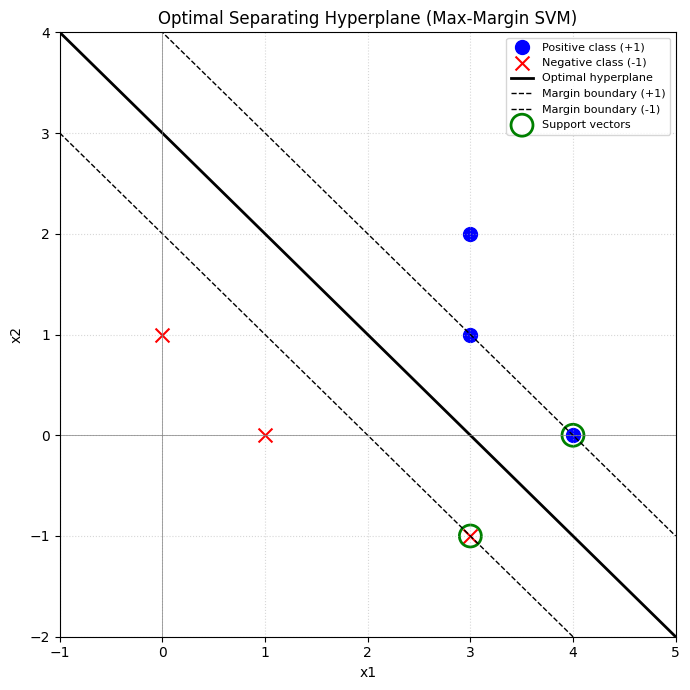

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# ---------------------------------------------------------
# Data
# ---------------------------------------------------------
positive_points = np.array([[3, 1], [3, 2], [4, 0]])
negative_points = np.array([[1, 0], [0, 1], [3, -1]])

X = np.vstack([positive_points, negative_points])
y = np.array([1, 1, 1, -1, -1, -1])

# ---------------------------------------------------------
# Fit the max-margin (optimal) separating hyperplane using SVM
# with a linear kernel and a large C (hard margin, since the
# data is linearly separable).
# ---------------------------------------------------------
clf = SVC(kernel="linear", C=1e6)
clf.fit(X, y)

w = clf.coef_[0]
b = clf.intercept_[0]
margin = 1 / np.linalg.norm(w)

print(f"Optimal hyperplane: {w[0]:.4f}*x1 + {w[1]:.4f}*x2 + {b:.4f} = 0")
print(f"Weight vector w = {w}")
print(f"Bias b = {b:.4f}")
print(f"Margin (distance from hyperplane to nearest point) = {margin:.4f}")
print(f"Support vectors:\n{clf.support_vectors_}")

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(positive_points[:, 0], positive_points[:, 1],
           color="blue", marker="o", s=100, label="Positive class (+1)")
ax.scatter(negative_points[:, 0], negative_points[:, 1],
           color="red", marker="x", s=100, label="Negative class (-1)")

# Decision boundary: w1*x1 + w2*x2 + b = 0  =>  x2 = -(w1*x1 + b)/w2
x1_range = np.linspace(-1, 5, 200)
x2_boundary = -(w[0] * x1_range + b) / w[1]
x2_margin_pos = -(w[0] * x1_range + b - 1) / w[1]
x2_margin_neg = -(w[0] * x1_range + b + 1) / w[1]

ax.plot(x1_range, x2_boundary, "k-", linewidth=2, label="Optimal hyperplane")
ax.plot(x1_range, x2_margin_pos, "k--", linewidth=1, label="Margin boundary (+1)")
ax.plot(x1_range, x2_margin_neg, "k--", linewidth=1, label="Margin boundary (-1)")

# Highlight support vectors
ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
           s=250, facecolors="none", edgecolors="green", linewidths=2,
           label="Support vectors")

ax.set_xlim(-1, 5)
ax.set_ylim(-2, 4)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Optimal Separating Hyperplane (Max-Margin SVM)")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/optimal_hyperplane.png", dpi=150)
print("\nPlot saved to optimal_hyperplane.png")

In [3]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

rng = np.random.RandomState(42)

# ===========================================================
# MLP FINE-TUNING APPROACH (realistic setup)
# -----------------------------------------------------------
# Source task : clean digit images (large dataset) -> PRE-TRAIN
# Target task : noisy digit images (small dataset)  -> FINE-TUNE
# Same 10 classes in both -> output layer can be reused directly.
# ===========================================================

digits = load_digits()
X, y = digits.data / 16.0, digits.target

X_source_train, X_temp, y_source_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Target domain = noisy version of a SMALL slice of the remaining data
X_target_pool, X_target_test, y_target_pool, y_target_test = train_test_split(
    X_temp, y_temp, test_size=0.6, random_state=42, stratify=y_temp
)

def add_noise(X, noise_level=0.4):
    noisy = X + rng.normal(0, noise_level, X.shape)
    return np.clip(noisy, 0, 1)

X_target_pool_noisy = add_noise(X_target_pool)
X_target_test_noisy = add_noise(X_target_test)

# Only use a SMALL slice of the noisy target pool to fine-tune,
# simulating "limited labeled data in the new domain"
X_target_train, _, y_target_train, _ = train_test_split(
    X_target_pool_noisy, y_target_pool, train_size=60, random_state=42, stratify=y_target_pool
)

print(f"Source (pre-training) samples: {len(X_source_train)}  [clean images]")
print(f"Target (fine-tuning) samples : {len(X_target_train)}  [noisy images, SMALL set]")
print(f"Target (test) samples        : {len(X_target_test_noisy)}  [noisy images]")

# ===========================================================
# STAGE 1: PRE-TRAIN on the source (clean) task
# ===========================================================
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    learning_rate_init=0.01,
    max_iter=300,
    random_state=42,
)
mlp.fit(X_source_train, y_source_train)
print(f"\n[Pre-trained model] accuracy on CLEAN test-ish data: "
      f"{accuracy_score(y_temp, mlp.predict(X_temp)):.4f}")
print(f"[Pre-trained model] accuracy on NOISY target test (no fine-tune): "
      f"{accuracy_score(y_target_test, mlp.predict(X_target_test_noisy)):.4f}")

# ===========================================================
# STAGE 2: FINE-TUNE the SAME network on the small noisy target set
# -----------------------------------------------------------
# warm_start=True + calling .fit() again on the SAME estimator
# continues training from the existing weights instead of
# reinitializing them. We also use a smaller learning rate.
# ===========================================================
mlp.set_params(learning_rate_init=0.001, max_iter=150, warm_start=True)
mlp.fit(X_target_train, y_target_train)  # continues from pre-trained weights

finetune_acc = accuracy_score(y_target_test, mlp.predict(X_target_test_noisy))
print(f"[Fine-tuned model] accuracy on NOISY target test: {finetune_acc:.4f}")

# ===========================================================
# BASELINE: train a FRESH MLP from scratch on the same small
# noisy target set (no pre-training) for comparison
# ===========================================================
mlp_scratch = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    learning_rate_init=0.01,
    max_iter=300,
    random_state=42,
)
mlp_scratch.fit(X_target_train, y_target_train)
scratch_acc = accuracy_score(y_target_test, mlp_scratch.predict(X_target_test_noisy))
print(f"[From-scratch model] accuracy on NOISY target test: {scratch_acc:.4f}")

print("\n=== Summary ===")
print(f"Fine-tuned MLP accuracy  : {finetune_acc:.4f}")
print(f"From-scratch MLP accuracy: {scratch_acc:.4f}")
if finetune_acc >= scratch_acc:
    print("-> Fine-tuning wins: reusing pre-trained features helps when")
    print("   the target (fine-tuning) dataset is small.")
else:
    print("-> From-scratch won this run; try increasing noise or shrinking")
    print("   the fine-tuning set further to see fine-tuning's advantage more clearly.")

Source (pre-training) samples: 1257  [clean images]
Target (fine-tuning) samples : 60  [noisy images, SMALL set]
Target (test) samples        : 324  [noisy images]

[Pre-trained model] accuracy on CLEAN test-ish data: 0.9759
[Pre-trained model] accuracy on NOISY target test (no fine-tune): 0.6728
[Fine-tuned model] accuracy on NOISY target test: 0.6852
[From-scratch model] accuracy on NOISY target test: 0.5463

=== Summary ===
Fine-tuned MLP accuracy  : 0.6852
From-scratch MLP accuracy: 0.5463
-> Fine-tuning wins: reusing pre-trained features helps when
   the target (fine-tuning) dataset is small.
